This notebook evaluates the robustness against rotation attacks of the FOVEA network after retraining. We examine how performance degrades as images are rotated and compare these results with the baseline networks tested in script `17_rotation_attack.ipynb` to assess the impact of foveation on rotational invariance.

# Evaluating FOVEA network robustness across multiple rotation angles

In [1]:
import retinoto_py as fovea
parms_dict = dict(shuffle=False, do_fovea=True,  do_augment=False, batch_size=500)
args = fovea.Params(**parms_dict)
# args

In [2]:
all_angles = fovea.np.linspace(0, 180, 25)
all_angles

array([  0. ,   7.5,  15. ,  22.5,  30. ,  37.5,  45. ,  52.5,  60. ,
        67.5,  75. ,  82.5,  90. ,  97.5, 105. , 112.5, 120. , 127.5,
       135. , 142.5, 150. , 157.5, 165. , 172.5, 180. ])

In [3]:
all_model_names = ['convnext_base']
all_datasets = ['bbox']
all_model_names, all_datasets

(['convnext_base'], ['bbox'])

In [4]:
delta_angle = all_angles[1] - all_angles[0]
all_angles_min = all_angles - delta_angle / 2
# all_angles_min, all_angles_min + delta_angle, delta_angle

In [5]:
for dataset in all_datasets:
    for model_name in all_model_names:
        npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
        print(f'Rotation attack for {model_name=} and {dataset=} \t {npz_filename=}')

        %ls -l {npz_filename}
        # %rm {npz_filename}  # FORCING RECOMPUTE

        if npz_filename.exists():
            with fovea.np.load(npz_filename) as data:
                attack_angle = data['attack_angle']
                attack_success = data['attack_success']
                all_results = data['results']
        else:
            args = fovea.Params(shuffle=False, do_fovea=True, do_augment=False, model_name=model_name, batch_size=500)
            model_filename = args.data_cache / f'32_fovea_model_name={args.model_name}_dataset={dataset}.pth'
            model = fovea.load_model(args, model_filename=model_filename)
            model.eval()

            VAL_DATA_DIR = args.DATAROOT / f'Imagenet_{dataset}' / 'val'
            val_dataset = fovea.get_dataset(args, VAL_DATA_DIR)
            val_loader = fovea.get_loader(args, val_dataset)

            # https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
            criterion = fovea.torch.nn.CrossEntropyLoss(reduction='none')
            all_results = fovea.np.empty((len(all_angles), len(val_loader.dataset)))
            all_logits = fovea.np.empty((len(all_angles), len(val_loader.dataset), len(val_dataset.classes)))
            all_losses = fovea.np.empty((len(all_angles), len(val_loader.dataset)))
            all_labels = []
            outer_progress = fovea.tqdm(
                                    enumerate(zip(all_angles_min, all_angles_min + delta_angle)),
                                    total=len(all_angles_min),
                                    desc="Validating Angles",
                                    leave=False
                                )
            for i_angle, (angle_min, angle_max) in outer_progress:
                val_dataset = fovea.get_dataset(args, VAL_DATA_DIR,
                                                angle_min=angle_min, angle_max=angle_max)
                val_loader = fovea.get_loader(args, val_dataset)

                # correct_predictions = 0
                # total_predictions = 0

                image_count = 0
                for images, true_idxs in fovea.tqdm(val_loader, 
                                                    desc=f"Angle [{.5*(angle_min+angle_max):.1f}°]", 
                                                    position=1, leave=False):
                    images = images.to(args.device)
                    true_idxs = true_idxs.to(args.device)

                    # Get predictions (no need for gradients)
                    with fovea.torch.no_grad():
                        if i_angle==0: all_labels.extend([l.item() for l in true_idxs])
                        outputs = model(images)
                        all_logits[i_angle, image_count:(image_count + images.size(0)), :] = outputs.cpu().numpy()

                        _, predicted_labels = fovea.torch.max(outputs, dim=1)
                        correct_predictions_in_batch = (predicted_labels == true_idxs).cpu().numpy()

                        all_results[i_angle, image_count:image_count + images.size(0)] = correct_predictions_in_batch
                        loss = criterion(outputs, true_idxs)
                        all_losses[i_angle, image_count:(image_count + images.size(0))] = loss.cpu().numpy()
                    image_count += images.size(0)
                outer_progress.set_postfix(last_acc=f"{all_results[i_angle, :].mean():.4f}")

            attack_angle = all_losses[:, :len(all_labels)].argmax(axis=0)
            attack_idx = all_logits[attack_angle[:len(all_labels)], fovea.np.arange(len(all_labels)), :].argmax(axis=1)
            attack_success = (attack_idx == all_labels)

            fovea.np.savez(npz_filename,
                    attack_angle=attack_angle,
                    attack_success=attack_success,
                    results=all_results)



Rotation attack for model_name='convnext_base' and dataset='bbox' 	 npz_filename=PosixPath('cached_data/37_rotation-attack_name=convnext_base_dataset=bbox.npz')
-rw-r--r--@ 1 laurent  staff  16815784 17 mai   01:00 cached_data/37_rotation-attack_name=convnext_base_dataset=bbox.npz


# Analysis: Mean accuracy vs. rotation angle

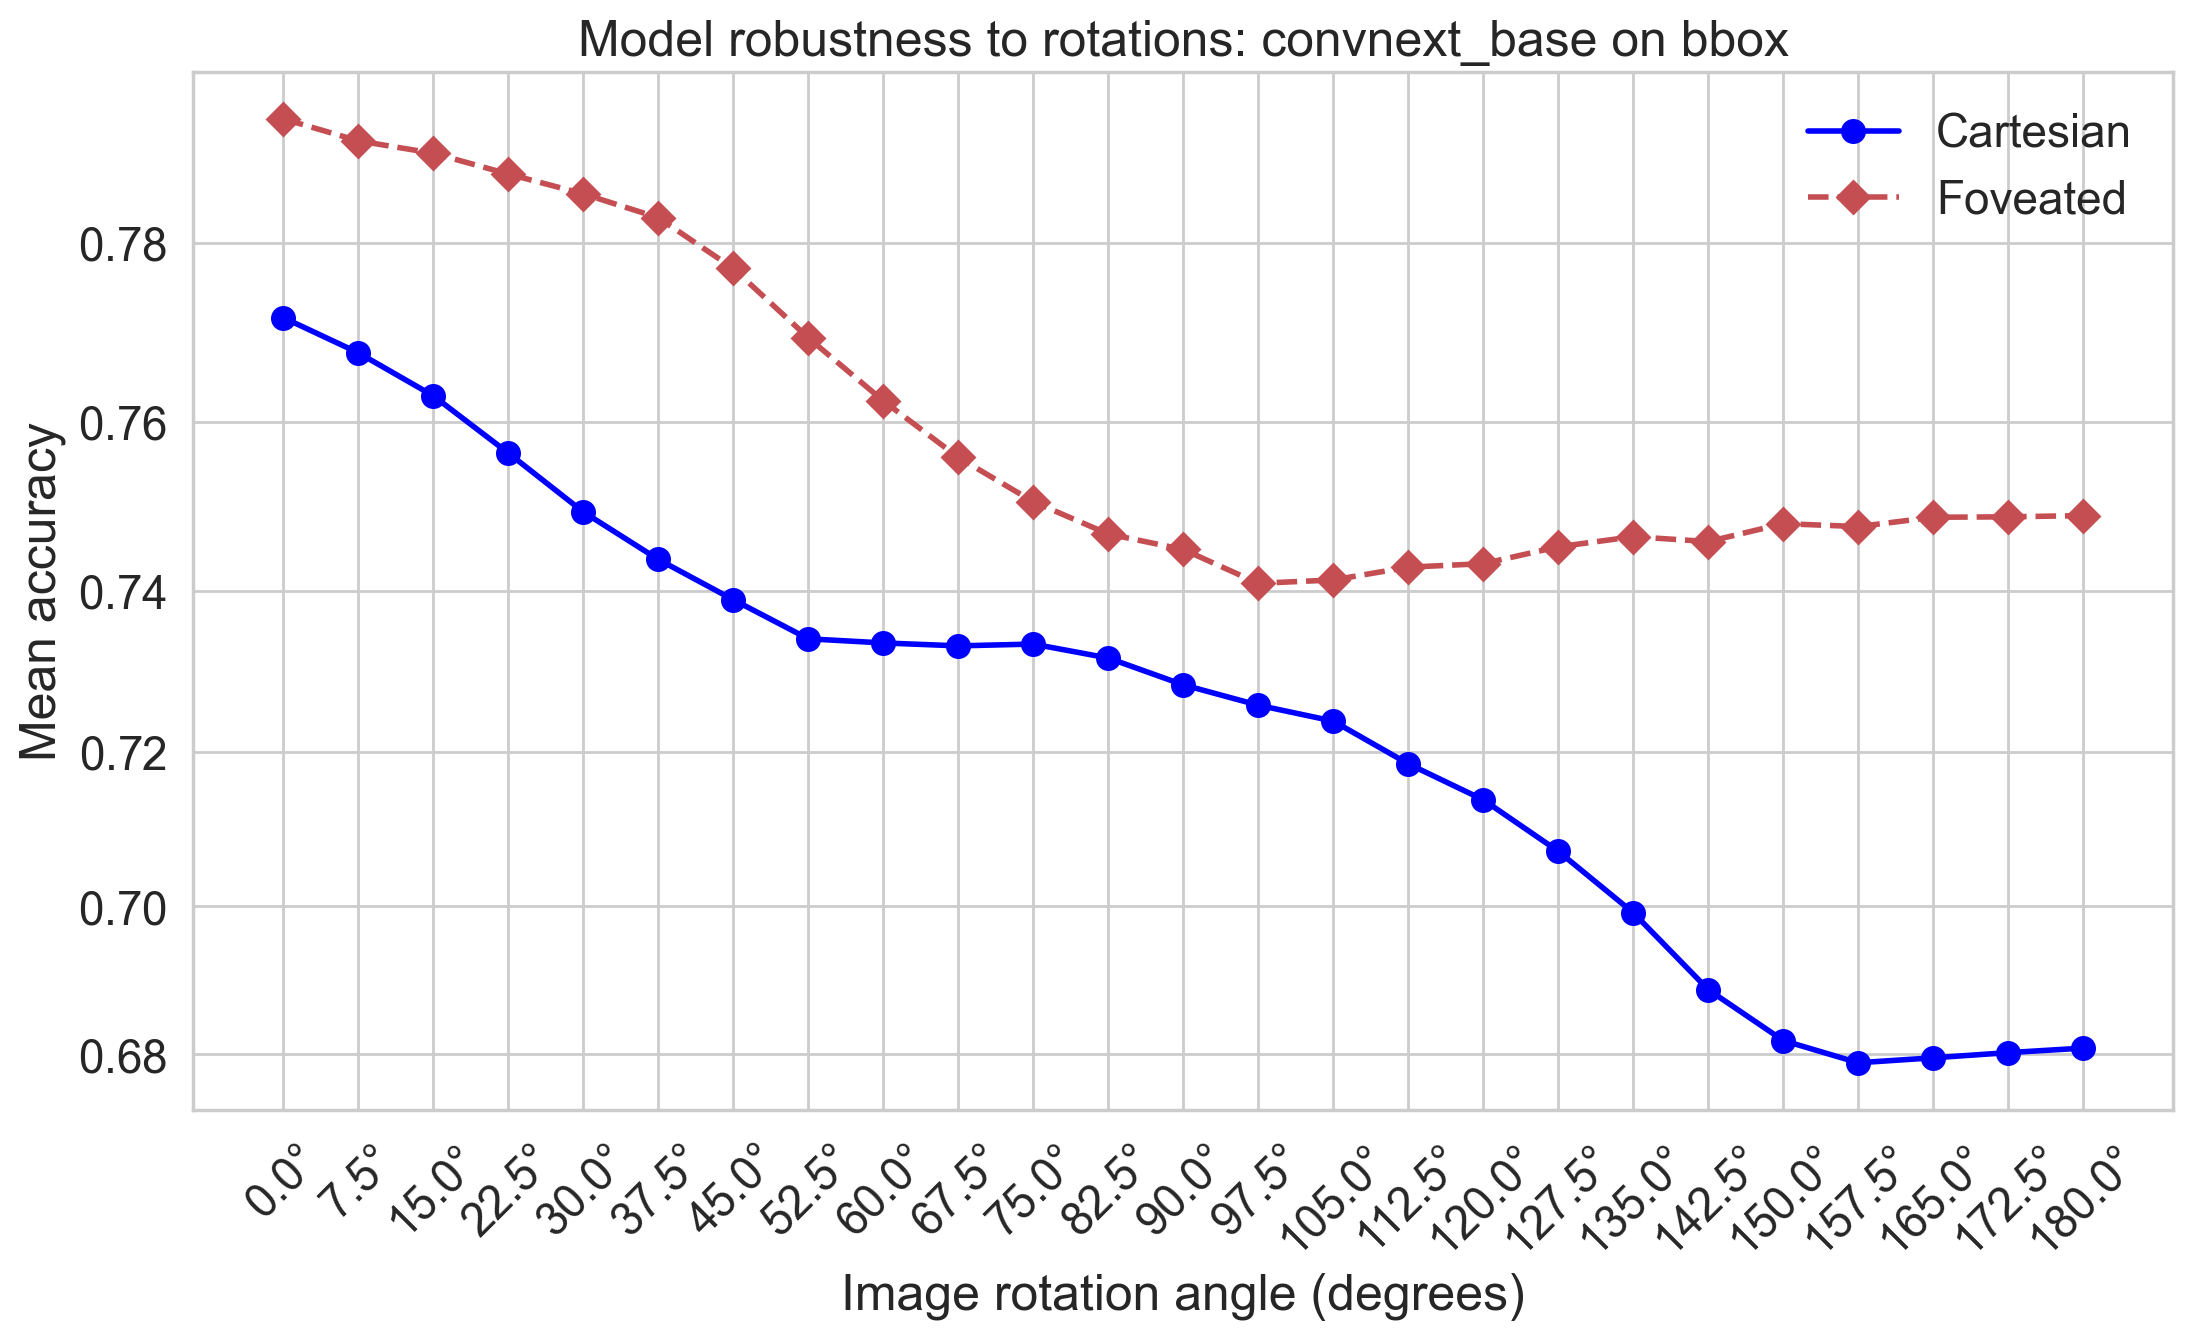

In [6]:
# --- Create the Plot ---
fig, ax = fovea.plt.subplots()

for dataset in all_datasets:
    color = fovea.params.all_datasets_color[0] if len(all_datasets)==1 else fovea.params.all_datasets_color[all_datasets.index(dataset)]
    color = fovea.params.all_datasets_color[0] if len(all_datasets)==1 else fovea.params.all_datasets_color[all_datasets.index(dataset)]
    
    # 1. Plot Baseline (from script 17)
    for model_name in all_model_names:
        npz_baseline = args.data_cache / f'17_rotation-attack_name={model_name}_dataset={dataset}.npz'
        if npz_baseline.exists():
            with fovea.np.load(npz_baseline) as data:
                acc = data['results'].mean(axis=1)
            ax.plot(all_angles, acc, marker='o', linestyle='-', color=color, lw=2, markersize=8, label=f'Cartesian')

    # 2. Plot Foveated Retrained (from script 37)
    for model_name in all_model_names:
        npz_fovea = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
        if npz_fovea.exists():
            with fovea.np.load(npz_fovea) as data:
                acc = data['results'].mean(axis=1)
            ax.plot(all_angles, acc, marker='D', linestyle='--', color='r', lw=2, markersize=8, label=f'Foveated')

# --- Finalize the Plot ---
ax.set_xlabel("Image rotation angle (degrees)")
ax.set_ylabel("Mean accuracy")
ax.set_title(f"Model robustness to rotations: {model_name} on {dataset}")
ax.set_yscale('logit')
ax.set_xticks(all_angles)
ax.set_xticklabels([f'{a:.1f}°' for a in all_angles], rotation=45)
ax.legend(frameon=False)
fovea.savefig(fig, name='37_attack_comparison', figures_folder=args.figures_folder, exts=['pdf'])


# Analysis: Per-image rotation attack success rate

In [7]:
with fovea.np.load(npz_filename) as data:
    # Accéder directement aux tableaux
    attack_angle = data["attack_angle"]
    attack_success = data["attack_success"]
    all_results = data["results"]

In [8]:
attack_angle.shape, attack_success.shape

((80000,), (80000,))

In [9]:
attack_angle[:10], attack_success[:10]

(array([12, 18, 16, 13, 20,  1,  3,  6, 21,  7]),
 array([ True, False,  True,  True,  True,  True,  True,  True,  True,
         True]))

In [10]:
fovea.np.unique(attack_angle)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24])

In [11]:
all_angles

array([  0. ,   7.5,  15. ,  22.5,  30. ,  37.5,  45. ,  52.5,  60. ,
        67.5,  75. ,  82.5,  90. ,  97.5, 105. , 112.5, 120. , 127.5,
       135. , 142.5, 150. , 157.5, 165. , 172.5, 180. ])

In [12]:
attack_success

array([ True, False,  True, ...,  True,  True,  True], shape=(80000,))

In [13]:
attack_success.mean()

np.float64(0.621925)

In [14]:
all_model_names

['convnext_base']

In [15]:
fovea.params.all_datasets

['full', 'bbox']

In [16]:
for dataset in fovea.params.all_datasets:
    for model_name in all_model_names:
        npz_filename = args.data_cache / f'17_rotation-attack_name={model_name}_dataset={dataset}.npz'
        with fovea.np.load(npz_filename) as data:
            attack_success = data['attack_success']
            print(npz_filename, attack_success.mean())

cached_data/17_rotation-attack_name=convnext_base_dataset=full.npz 0.65474
cached_data/17_rotation-attack_name=convnext_base_dataset=bbox.npz 0.58965


In [17]:
for dataset in all_datasets:
    for model_name in all_model_names:
        npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
        with fovea.np.load(npz_filename) as data:
            attack_success = data['attack_success']
            print(npz_filename, attack_success.mean())

cached_data/37_rotation-attack_name=convnext_base_dataset=bbox.npz 0.621925


In [18]:
attack_angle


array([12, 18, 16, ..., 19, 10,  4], shape=(80000,))